<a href="https://colab.research.google.com/github/tamaravdd/iese-dsmba/blob/main/notebooks/06_Merging_Timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 6 · Time Series Data
## Bitcoin Price Analysis — Reading the Market Story

**Session objectives**
1. Merge pandas dataframes
2. Work with `DatetimeIndex` to slice and filter by date
3. Compute returns, apply resampling and rolling windows
---


In [1]:
# loading the libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')

## Business Context

Bitcoin hit an all-time high after the U.S. election in November 2024. As a **risk analyst**, your job is to:

1. Quantify the typical volatility of Bitcoin over the past year
2. Calculate Value at Risk (VaR) and explain it to a non-technical stakeholder
3. Identify any day-of-week patterns in returns
4. Visualize the price trend with an annotated narrative

---

> 🧠 **Before running any code — write your hypotheses:**
> - Do you expect Bitcoin to be more or less volatile than the S&P 500?
> - Which days of the week do you expect to have the highest returns?
> - What major events do you think would show up in a 2024 price chart?

---
## Part 1 — Load & Index

### 1.1 Load the Bitcoin data

We will use Coinmarketcap to obtain the price series of Bitcoin over the past year. They have both an API or a website where you can download the data:

[https://coinmarketcap.com/currencies/bitcoin/historical-data/](https://coinmarketcap.com/currencies/bitcoin/historical-data/)

You can also download the corresponding bitcoin chart that I downloaded a year ago:

In [2]:
# local download
# df = pd.read_csv('./data_raw/BTC.csv', delimiter=';')

# google drive download
#from google.colab import drive
#drive.mount('/content/drive')
#df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data_raw/BTC.csv", delimiter=';')

# quick fix: download from github url
df = pd.read_csv("https://raw.githubusercontent.com/tamaravdd/iese-dsmba/refs/heads/main/data_raw/BTC.csv", delimiter=';')

df.head()
df.info()
print(f'Loaded: {df.shape[0]} rows')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timeOpen   364 non-null    object 
 1   timeClose  364 non-null    object 
 2   timeHigh   364 non-null    object 
 3   timeLow    364 non-null    object 
 4   name       364 non-null    int64  
 5   open       364 non-null    float64
 6   high       364 non-null    float64
 7   low        364 non-null    float64
 8   close      364 non-null    float64
 9   volume     364 non-null    float64
 10  marketCap  364 non-null    float64
 11  timestamp  364 non-null    object 
dtypes: float64(6), int64(1), object(5)
memory usage: 34.3+ KB
Loaded: 364 rows


In [3]:
# select the columns we are interested in
df = df[['timestamp', 'open', 'high', 'low', 'close', 'volume']]

df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
print(f'New Loaded: {df.shape[0]} rows')
df.head(3)

New Loaded: 364 rows


,Date,Open,High,Low,Close,Volume
0,2025-04-22T23:59:59.999Z,87521.8712,93817.3838,87084.5294,93441.8933,55899038455.7300
1,2025-04-21T23:59:59.999Z,85171.5428,88460.0962,85143.8377,87518.9050,41396190189.8800
2,2025-04-20T23:59:59.999Z,85066.0689,85306.3813,83976.8458,85174.3016,14664050811.9300


> ✅ **Sanity check:** confirm that we did not lose any rows

### 1.2 Convert date and set as index

This is the crucial step that unlocks all time series functionality.

In [4]:
# Step 1: Convert string to datetime
# Dates are in ISO 8601 format (e.g., '2024-05-01T00:00:00.000Z')
# Ask an LLM when you're unsure of the format — paste a sample date
df['Date'] = pd.to_datetime(df['Date'], utc=True)

# Step 2: Set as index and sort
# since Date is the key identifier, it's appropriate to remove it
# from the columns and set it as index instead, we also sort by date
df = df.set_index('Date').sort_index()

> ✅ **Sanity check:**  Confirm the index row are dates and ordered correctly

In [5]:
df.index

DatetimeIndex(['2024-04-24 23:59:59.999000+00:00',
               '2024-04-25 23:59:59.999000+00:00',
               '2024-04-26 23:59:59.999000+00:00',
               '2024-04-27 23:59:59.999000+00:00',
               '2024-04-28 23:59:59.999000+00:00',
               '2024-04-29 23:59:59.999000+00:00',
               '2024-04-30 23:59:59.999000+00:00',
               '2024-05-01 23:59:59.999000+00:00',
               '2024-05-02 23:59:59.999000+00:00',
               '2024-05-03 23:59:59.999000+00:00',
               ...
               '2025-04-13 23:59:59.999000+00:00',
               '2025-04-14 23:59:59.999000+00:00',
               '2025-04-15 23:59:59.999000+00:00',
               '2025-04-16 23:59:59.999000+00:00',
               '2025-04-17 23:59:59.999000+00:00',
               '2025-04-18 23:59:59.999000+00:00',
               '2025-04-19 23:59:59.999000+00:00',
               '2025-04-20 23:59:59.999000+00:00',
               '2025-04-21 23:59:59.999000+00:00',
            

In [6]:
# Sanity check: what type is the index now?
print('Index type:', type(df.index))
print('First date:', df.index[0])
print('Last date: ', df.index[-1])
df.head(3)

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
First date: 2024-04-24 23:59:59.999000+00:00
Last date:  2025-04-22 23:59:59.999000+00:00


,Open,High,Low,Close,Volume
Date,,,,,
2024-04-24 23:59:59.999000+00:00,66408.7221,67075.3696,63589.8719,64276.8974,30276655120.0200
2024-04-25 23:59:59.999000+00:00,64275.0210,65275.2075,62783.6333,64481.7066,32155786816.0100
2024-04-26 23:59:59.999000+00:00,64485.3699,64789.6575,63322.3996,63755.3213,24139372950.1500


> ✅ **Sanity check:** The index should say `DatetimeIndex`, not `RangeIndex` or `Index`. If it still shows `RangeIndex`, the `set_index` step failed — check that `Date` is the correct column name.

### 1.3 Explore and slice by date

In [7]:
df.info()  # note the DatetimeIndex and dtypes

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 364 entries, 2024-04-24 23:59:59.999000+00:00 to 2025-04-22 23:59:59.999000+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    364 non-null    float64
 1   High    364 non-null    float64
 2   Low     364 non-null    float64
 3   Close   364 non-null    float64
 4   Volume  364 non-null    float64
dtypes: float64(5)
memory usage: 17.1 KB


In [8]:
df.describe()

,Open,High,Low,Close,Volume
count,364.0000,364.0000,364.0000,364.0000,364.0000
mean,76790.7366,78316.3218,75256.4768,76864.6222,40032114489.8960
std,15708.8650,16035.0162,15348.8666,15722.4103,23604278538.5835
min,53949.0872,54838.1457,49121.2374,53948.7522,9858198792.6100
25%,63093.5709,64161.0409,62123.3230,63097.4136,25464619106.1575
50%,69310.8357,70221.5449,68511.5399,69351.0765,32980233977.0450
75%,93685.4447,95218.5892,91433.6796,93688.8864,47470136981.0750
max,106147.2953,109114.8848,105291.7379,106146.2630,149218945579.6500


In [9]:
# Slice by date — reads like a sentence
df.loc['2024-11-01':'2024-11-30'].describe()  # November 2024 — the post-election surge

,Open,High,Low,Close,Volume
count,30.0000,30.0000,30.0000,30.0000,30.0000
mean,85696.2170,88053.2606,84430.8647,86570.7080,68526962508.8323
std,10766.5016,10757.1279,10472.4889,10529.1989,29916551457.7022
min,67811.1743,69361.6580,66803.6500,67811.5091,18184612091.3200
25%,76066.1722,77020.5254,75680.0030,76603.8244,46122706729.4675
50%,90190.2635,91816.9829,87933.2833,90550.5596,67300553713.8100
75%,94022.8025,97183.4374,92426.8514,95324.2226,82155311493.4050
max,99006.7423,99655.5011,97232.8931,98997.6621,133673285374.5000


The structure of the index also helps to select the data in special ways. For instance, to select the Friday opening prices, you can apply the function `day_name` to the index:

In [10]:
# Filter by day of week
df[df.index.day_name() == 'Friday'].head(5)

,Open,High,Low,Close,Volume
Date,,,,,
2024-04-26 23:59:59.999000+00:00,64485.3699,64789.6575,63322.3996,63755.3213,24139372950.1500
2024-05-03 23:59:59.999000+00:00,59122.3009,63320.5034,58848.3121,62889.8367,33172023048.2000
2024-05-10 23:59:59.999000+00:00,63055.1910,63446.7425,60208.7815,60792.7768,27804954694.2200
2024-05-17 23:59:59.999000+00:00,65231.2987,67459.4595,65119.3150,67051.8749,28031279309.7200
2024-05-24 23:59:59.999000+00:00,67928.1303,69220.2939,66622.6687,68526.0978,29197308152.6200


Alternatively, you could use `df.index.month == 11`. To select the opening prices from a particular month:

In [11]:
# Filter by month
df[df.index.month == 11].head(5)  # November only

,Open,High,Low,Close,Volume
Date,,,,,
2024-11-01 23:59:59.999000+00:00,70216.8970,71559.0166,68779.7003,69482.4699,49989795365.0900
2024-11-02 23:59:59.999000+00:00,69486.0239,69867.3519,69033.7223,69289.2767,18184612091.3200
2024-11-03 23:59:59.999000+00:00,69296.3821,69361.6580,67482.5254,68741.1155,34868307655.1800
2024-11-04 23:59:59.999000+00:00,68742.1347,69433.1764,66803.6500,67811.5091,41184819348.3300
2024-11-05 23:59:59.999000+00:00,67811.1743,70522.7868,67458.8697,69359.5662,46046889204.1300


### 1.4 Plot the price with annotations

A price chart without context is just noise. We annotate key events to tell a story.

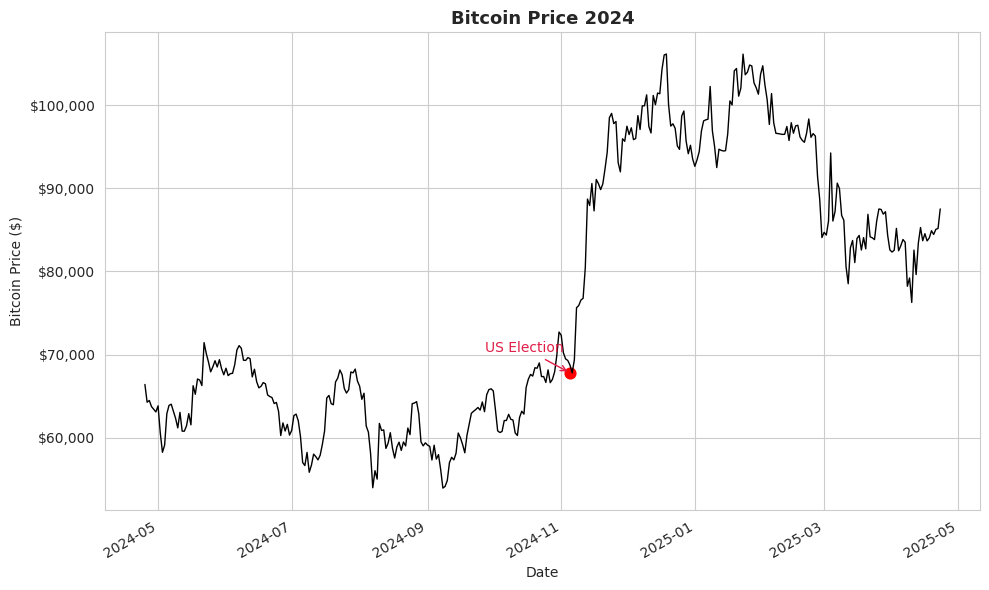

In [12]:
# Base plot (simple)
df['Open'].plot(figsize=(10, 6), color='black', linewidth=1, ylabel='Bitcoin Price ($)'
)

# Key date + value
election_date = pd.Timestamp('2024-11-05')
election_price = df.loc['2024-11-05', 'Open'].item()

# Highlight point
plt.scatter(election_date, election_price, color='r', s=60)

# Simple annotation
plt.annotate(
    "US Election",
    xy=(election_date, election_price),
    xytext=(pd.Timestamp('2024-10-15'), election_price + 2500),
    arrowprops=dict(arrowstyle='->', color='#E11D48'),
    color='#E11D48',
    ha='center'
)

# Formatting
plt.title('Bitcoin Price 2024', fontsize=13, weight='bold')
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)


plt.tight_layout()
plt.show()

> 🧠 **Pause and Think:** Add one more annotation to the chart — pick a date where you see a notable move and explain what happened.

## Part 2 Merging Datasets: Stock comparison


How does Bitcoin compare to traditional assets over the same period?

#### Microsoft vs. Apple Analysis

We could do a similar analysis for more traditional stocks like Apple and Microsoft. For this, let's use  `yfinance` (installed using `! pip install yfinance`).

In [13]:
# run this once and then comment it out
# !pip install yfinance

In [14]:
import yfinance as yf

# We set the start and end dates to be the beginning and end of our Bitcoin data
start_date = df.index.min().strftime('%Y-%m-%d')
end_date   = df.index.max().strftime('%Y-%m-%d')

# Download Apple and Microsoft data
df_aapl = yf.download('AAPL', start=start_date, end=end_date, auto_adjust=True)
df_msft = yf.download('MSFT', start=start_date, end=end_date, auto_adjust=True)

df_aapl.columns = [col[0] for col in df_aapl.columns]
df_msft.columns = [col[0] for col in df_msft.columns]

# if it doesn't work, you can use this download form the course's github
#df_aapl = pd.read_csv("https://raw.githubusercontent.com/tamaravdd/iese-dsmba/refs/heads/main/resources/AAPL.csv", delimiter=',')
#df_msft = pd.read_csv("https://raw.githubusercontent.com/tamaravdd/iese-dsmba/refs/heads/main/resources/BTC.csv", delimiter=';')

print('AAPL rows:', len(df_aapl), '| MSFT rows:', len(df_msft))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

AAPL rows: 248 | MSFT rows: 248


To compare the three trends we need new tools: `pd.merge()` (for tables that share a common column) and its cousin `.join()` ( for tables that share an index (handy for time series)).

#### 2.1 `merge()` — joining on a shared column

`merge()` aligns two tables by matching values in a column — like a VLOOKUP in Excel.

![Merge](https://raw.githubusercontent.com/tamaravdd/iese-dsmba/main/images/join-types-python-merge-programming.png)



```python
result = left_df.merge(right_df, on='key_column', how='left')
```

- `on=` — which column(s) to match rows on
- `how=` — what to do when there's no match:
  - `'left'` — keep all rows from `left_df`, fill `NaN` if no match in `right_df`
  - `'inner'` — keep only rows that match in both
  - `'outer'` — keep all rows from both, fill `NaN` where there's no match

Here is a quick example before we use it on real data:


In [15]:
## our data

# Quick example: stock prices and sector labels in two separate tables
prices = pd.DataFrame({
    'ticker': ['AAPL', 'MSFT', 'GOOG'],
    'price':  [213,    415,    178]
})

sectors = pd.DataFrame({
    'ticker': ['AAPL', 'MSFT', 'NVDA'],   # NVDA has no price; GOOG has no sector
    'sector': ['Technology', 'Technology', 'Technology']
})

# inner: only rows that appear in BOTH tables
pd.merge(prices, sectors, on='ticker', how='inner')


,ticker,price,sector
0,AAPL,213,Technology
1,MSFT,415,Technology


In [16]:
# left: keep every row from prices, fill NaN where no sector match exists
pd.merge(prices, sectors, on='ticker', how='left')

,ticker,price,sector
0,AAPL,213,Technology
1,MSFT,415,Technology
2,GOOG,178,NaN


### 2.2 `.join()` — joining on the index

For time series the date *is* the index, so `.join()` is cleaner — it aligns rows by index automatically, no `on=` needed.

In [17]:
# Same idea as merge, but matching on the index instead of a column
a = pd.DataFrame(
    {'price_A': [100, 102, 105]},
    index=pd.to_datetime(['2024-01-01', '2024-01-02', '2024-01-03'])
)
b = pd.DataFrame(
    {'price_B': [50, 51, 49]},
    index=pd.to_datetime(['2024-01-01', '2024-01-02', '2024-01-04'])  # Jan 4, not Jan 3
)

# inner: only dates present in both
a.join(b, how='inner')

,price_A,price_B
2024-01-01,100,50
2024-01-02,102,51


### 2.3 join() vs merge()

| | `merge()` | `.join()` |
|---|---|---|
| Match on | a shared **column** | the **index** |
| Typical use | sales + customer tables | time series aligned by date |
| Syntax | `df1.merge(df2, on='key')` | `df1.join(df2)` |

For our stock comparison, `.join()` is the right tool — all three DataFrames already have a `DatetimeIndex`.


### 2.4 Join the three datasets and plot

Extract the `Close` price from each, rename the columns, then join on the shared index.


In [18]:
# double check the index is indeed date-time format
df_aapl.info()
df_msft.info()

# remove the timezone from BTC because not present in the others
btc_close  = df[['Close']].rename(columns={'Close': 'BTC'})
btc_close.index = btc_close.index.tz_localize(None)  # strip UTC from BTC
btc_close.index = btc_close.index.normalize()  # rounds down to midnight

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2024-04-24 to 2025-04-21
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   248 non-null    float64
 1   High    248 non-null    float64
 2   Low     248 non-null    float64
 3   Open    248 non-null    float64
 4   Volume  248 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.6 KB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2024-04-24 to 2025-04-21
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   248 non-null    float64
 1   High    248 non-null    float64
 2   Low     248 non-null    float64
 3   Open    248 non-null    float64
 4   Volume  248 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.6 KB


In [19]:
# Step 1: extract Close price from each DataFrame and give it a clear name
aapl_close = df_aapl[['Close']].rename(columns={'Close': 'AAPL'})
msft_close = df_msft[['Close']].rename(columns={'Close': 'MSFT'})

# Verify all three are similarly coded
print(btc_close.index[:1])
print(aapl_close.index[:1])
print(msft_close.index[:1])


DatetimeIndex(['2024-04-24'], dtype='datetime64[ns]', name='Date', freq='D')
DatetimeIndex(['2024-04-24'], dtype='datetime64[ns]', name='Date', freq=None)
DatetimeIndex(['2024-04-24'], dtype='datetime64[ns]', name='Date', freq=None)


In [20]:

# Step 2: join on the DatetimeIndex (let's only keep the dates that are available to all)
combined = btc_close.join(aapl_close, how='inner').join(msft_close, how='inner')

print('Combined shape:', combined.shape)
combined.head(3)

Combined shape: (248, 3)


,BTC,AAPL,MSFT
Date,,,
2024-04-24,64276.8974,167.3415,402.0056
2024-04-25,64481.7066,168.2029,392.1585
2024-04-26,63755.3213,167.6187,399.3129


> ✅ **Sanity check:** `combined` should have 3 columns (BTC, AAPL, MSFT) and roughly as many rows as there are weekdays in the date range.

The three price series are now in one DataFrame — but they are in completely different units (usd70k vs usd200 vs usd400). To compare them fairly, we **normalize to 100** at the start date: every value then shows 'what is $100 worth today?'

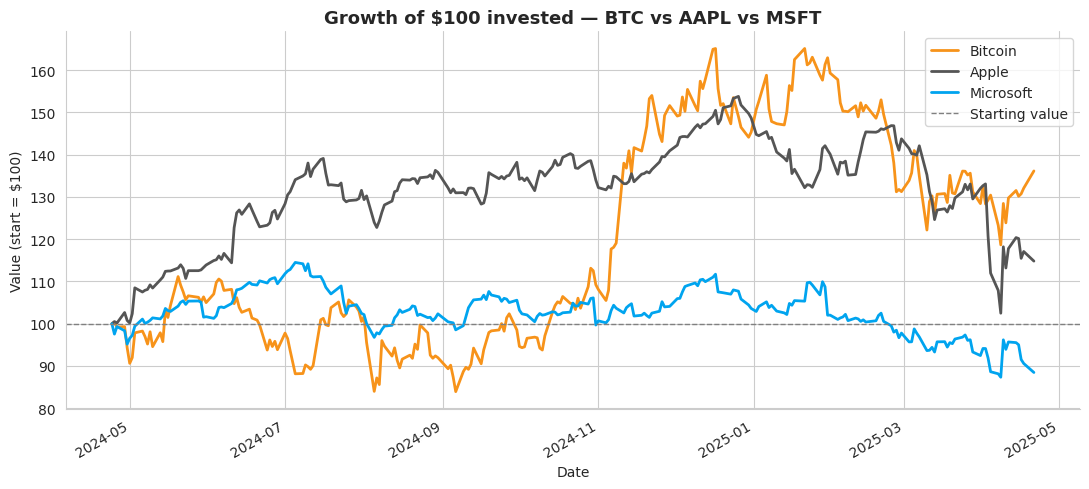

In [21]:
# Normalize: divide every column by its first value, multiply by 100
normalized = combined / combined.iloc[0] * 100

fig, ax = plt.subplots(figsize=(11, 5))
normalized['BTC'].plot( ax=ax, color='#F7931A', linewidth=2, label='Bitcoin')
normalized['AAPL'].plot(ax=ax, color='#555555', linewidth=2, label='Apple')
normalized['MSFT'].plot(ax=ax, color='#00A4EF', linewidth=2, label='Microsoft')

ax.axhline(100, color='gray', linestyle='--', linewidth=1, label='Starting value')
ax.set_title('Growth of $100 invested — BTC vs AAPL vs MSFT', fontsize=13, fontweight='bold')
ax.set_ylabel('Value (start = $100)')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

---
## Part 3 — Returns & Risk



### 3.1 Daily returns

Analysts work with **returns** (% change) rather than prices, because returns are comparable across assets and time periods.

In [22]:
# Daily return = today's close / yesterday's close - 1
# pct_change() does this automatically — but data must be sorted first!
df_return = df['Close'].pct_change()

 >✅  Sanity check: the first return should be NaN (no previous day), check the first calculated values

In [23]:
print('First few returns:')
print(df_return.head())
print(f'\nMean daily return: {df_return.mean():.4f} ({df_return.mean()*100:.2f}%)')
print(f'Daily std dev:     {df_return.std():.4f} ({df_return.std()*100:.2f}%)')

First few returns:
Date
2024-04-24 23:59:59.999000+00:00       NaN
2024-04-25 23:59:59.999000+00:00    0.0032
2024-04-26 23:59:59.999000+00:00   -0.0113
2024-04-27 23:59:59.999000+00:00   -0.0053
2024-04-28 23:59:59.999000+00:00   -0.0048
Name: Close, dtype: float64

Mean daily return: 0.0014 (0.14%)
Daily std dev:     0.0270 (2.70%)


The daily returns can be plotted in the same way as the prices:

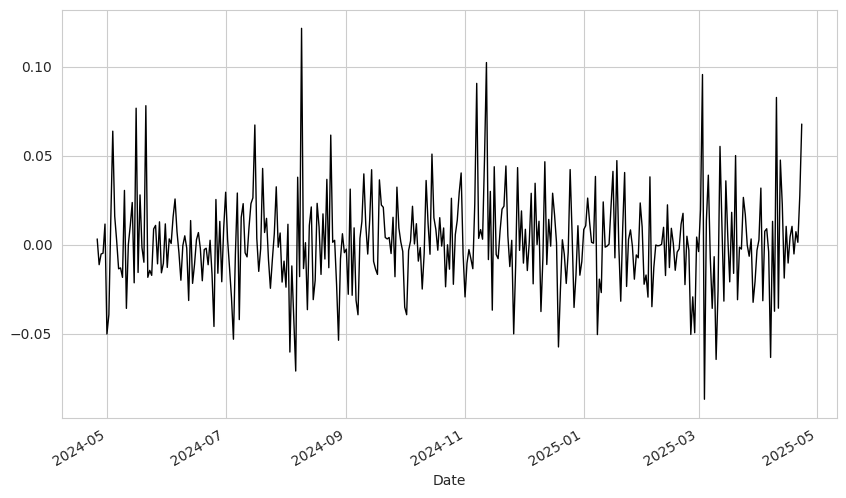

In [24]:
df_return.plot(figsize=(10,6), color='black', linewidth=1);

>✅ **Sanity check:** Are there any returns > 50% or < -50%? If so, check whether those dates correspond to known events, or whether there's a data issue.

### 3.2 Value at Risk (VaR)

**VaR** answers: *What's the worst daily loss we should expect on 95% of trading days?*

Mathematically: the 5th percentile of the return distribution.

In [25]:
confidence_level = 0.95
var_quantile     = 1 - confidence_level
var_value        = df_return.quantile(var_quantile)

print(f'95% VaR: {var_value:.4f} ({var_value*100:.2f}%)')
print()
print('How to read this:')
print(f'  On 95% of trading days, daily loss should not exceed {abs(var_value)*100:.1f}%.')
print(f'  On 1 in 20 days, however, we may lose more.')

95% VaR: -0.0391 (-3.91%)

How to read this:
  On 95% of trading days, daily loss should not exceed 3.9%.
  On 1 in 20 days, however, we may lose more.


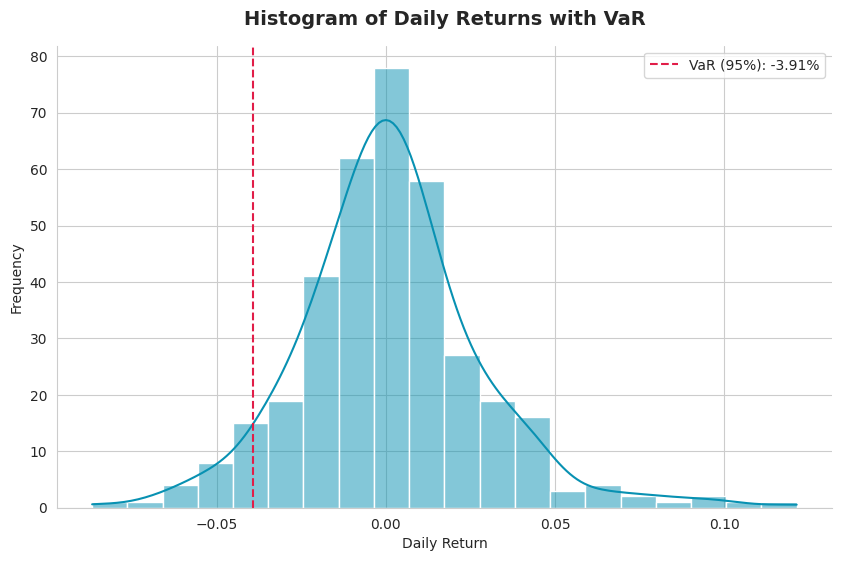

In [26]:
# visualize it

plt.figure(figsize=(10, 6))
sns.histplot(df_return, bins=20, kde=True, color='#0891B2', edgecolor='white')
plt.axvline(var_value, color='#E11D48', linestyle='--', label=f'VaR ({int(confidence_level*100)}%): {var_value:.2%}')
plt.title('Histogram of Daily Returns with VaR', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
sns.despine()
plt.grid(True)
plt.show()


# ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))


**Weekly returns**

Weekly returns, based on the percentage change across Fridays, can be calculated after filtering out the rest of the days. Beware that this could be wrong for the weeks in which the Friday is not a trading day.

In [27]:
df_w_return = df[df.index.day_name() == 'Friday']['Close'].pct_change()
df_w_return.head()

,Close
Date,
2024-04-26 23:59:59.999000+00:00,NaN
2024-05-03 23:59:59.999000+00:00,-0.0136
2024-05-10 23:59:59.999000+00:00,-0.0333
2024-05-17 23:59:59.999000+00:00,0.1030
2024-05-24 23:59:59.999000+00:00,0.0220


---
## Part 4 — Patterns in Time




### 4.1 Day-of-week effect

Does Bitcoin return more on certain days? (Unlike stock markets, crypto trades 24/7 — so every day matters.)

In [28]:
# Add day of week to the returns series
df['daily_return'] = df['Close'].pct_change()
df['day_name'] = df.index.day_name()

# Group by day and compute median return
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_returns = (
    df.groupby('day_name')['daily_return']
    .agg(['median', 'mean', 'std'])
    .loc[day_order]
    .round(4)
)

print('Median return by day of week:')
print((day_returns * 100).round(3))

Median return by day of week:
           median    mean    std
day_name                        
Monday     0.2700  0.2600 3.4100
Tuesday   -0.2100 -0.0100 2.7700
Wednesday -0.3400  0.4400 3.1700
Thursday  -0.2100 -0.1300 2.6700
Friday     0.6600  0.5700 2.7000
Saturday   0.0500  0.1700 0.9400
Sunday    -0.2000 -0.3300 2.5900


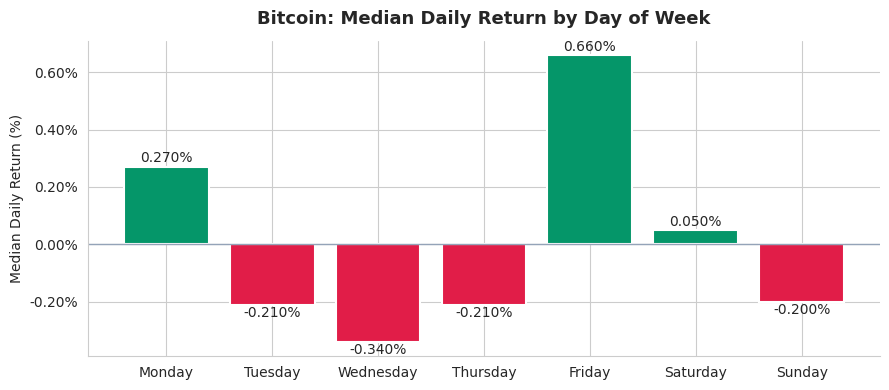

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#059669' if v >= 0 else '#E11D48' for v in day_returns['median']]

bars = ax.bar(day_returns.index, day_returns['median'] * 100,
              color=colors, edgecolor='white', linewidth=1.5)

ax.axhline(0, color='#94A3B8', linewidth=1)
ax.set_title('Bitcoin: Median Daily Return by Day of Week', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Median Daily Return (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}%'))

for bar, val in zip(bars, day_returns['median']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005 * (1 if val >= 0 else -1),
            f'{val*100:.3f}%', ha='center', va='bottom' if val >= 0 else 'top',
            fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

> 🔍 **Sanity check:** The differences between days are likely very small (fractions of a percent). If one day shows returns of +5% vs. -5% on other days, something is wrong — check whether that day has very few observations.

> **Interpretation:** Are these differences statistically meaningful, or just noise from ~52 Mondays in a year? With small samples, patterns can be illusory. This is a good moment to discuss the difference between *statistical* and *practical* significance.



### 4.2 Resampling: monthly view

Aggregating time series data by a new time period is often called **resampling**. The method `resample` is designed for Pandas data frames with a `DatetimeIndex`. In the following example, I apply this method to get the average weekly open price of Bitcoin.

In [30]:
# Resample to monthly — each point is the average open price for that month
monthly_price = df['Open'].resample('ME').mean()

This can also be done by week `resample('W')`

 >✅ **Sanity check**: how many rows should we have?

In [31]:
n_months = len(monthly_price)
print(f'Monthly rows: {n_months}  (expected: number of months in the dataset)')
monthly_price

Monthly rows: 13  (expected: number of months in the dataset)


,Open
Date,
2024-04-30 00:00:00+00:00,64184.2002
2024-05-31 00:00:00+00:00,65044.2126
2024-06-30 00:00:00+00:00,66057.7892
2024-07-31 00:00:00+00:00,62737.7648
2024-08-31 00:00:00+00:00,60103.8967
2024-09-30 00:00:00+00:00,60213.1928
2024-10-31 00:00:00+00:00,65361.9054
2024-11-30 00:00:00+00:00,85696.2170
2024-12-31 00:00:00+00:00,98341.1976


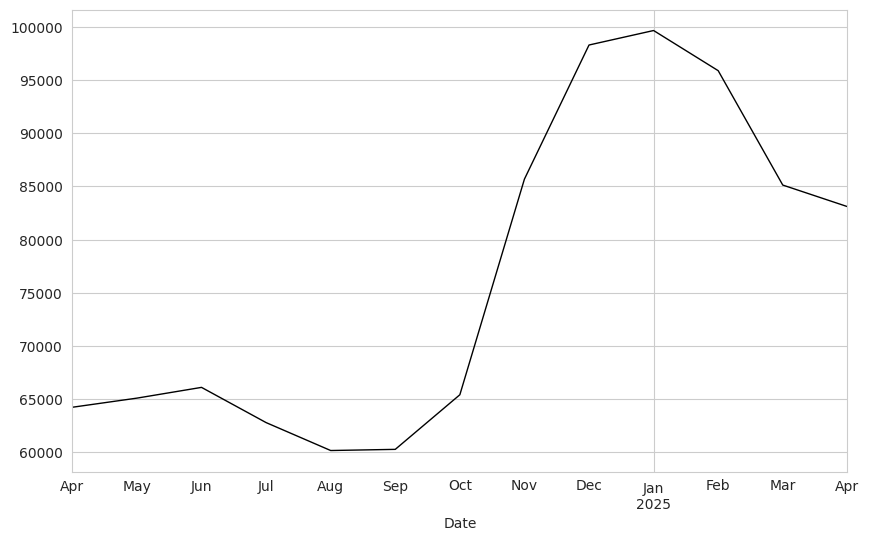

In [32]:
# we can plot the monthly prices then
monthly_price.plot(figsize=(10,6), color='black', linewidth=1);

### 4.3 Rolling windows: extracting the trend

The logic of `rolling` is similar to that of `resampling`, but it groups the rows around every value of the index (except at the extremes). The set of these groups is called a **rolling window**. This is easily seen in the following calculation, which extracts a **moving average** (MA) trend for the opening prices (moving average is a popular name for the rolling mean).

In [33]:
df['Open'].rolling(5).mean().head(10)

,Open
Date,
2024-04-24 23:59:59.999000+00:00,NaN
2024-04-25 23:59:59.999000+00:00,NaN
2024-04-26 23:59:59.999000+00:00,NaN
2024-04-27 23:59:59.999000+00:00,NaN
2024-04-28 23:59:59.999000+00:00,64468.7234
2024-04-29 23:59:59.999000+00:00,63808.2518
2024-04-30 23:59:59.999000+00:00,63721.1316
2024-05-01 23:59:59.999000+00:00,62945.9572
2024-05-02 23:59:59.999000+00:00,61846.5001


As a default, the terms included in the rolling window are collected leftwards. Here the length has been set to 5. So, the first 4 terms of the moving average are `NaN`'s. But you may prefer to center the window in the current observation. In that case, you will get 2 `NaN`'s at each extreme of the series. This is done with:

In [34]:
ma = df['Open'].rolling(5, center=True).mean()
ma.head(10)

,Open
Date,
2024-04-24 23:59:59.999000+00:00,NaN
2024-04-25 23:59:59.999000+00:00,NaN
2024-04-26 23:59:59.999000+00:00,64468.7234
2024-04-27 23:59:59.999000+00:00,63808.2518
2024-04-28 23:59:59.999000+00:00,63721.1316
2024-04-29 23:59:59.999000+00:00,62945.9572
2024-04-30 23:59:59.999000+00:00,61846.5001
2024-05-01 23:59:59.999000+00:00,60986.2575
2024-05-02 23:59:59.999000+00:00,60943.1908


A moving average is frequently used to create a **nonparametric trend**, that is, a trend which is not given as a mathematical function of time, like a linear or quadratic trend. The chart below illustrates this. The dashed line corresponds to the actual prices, and the solid line to the MA trend.

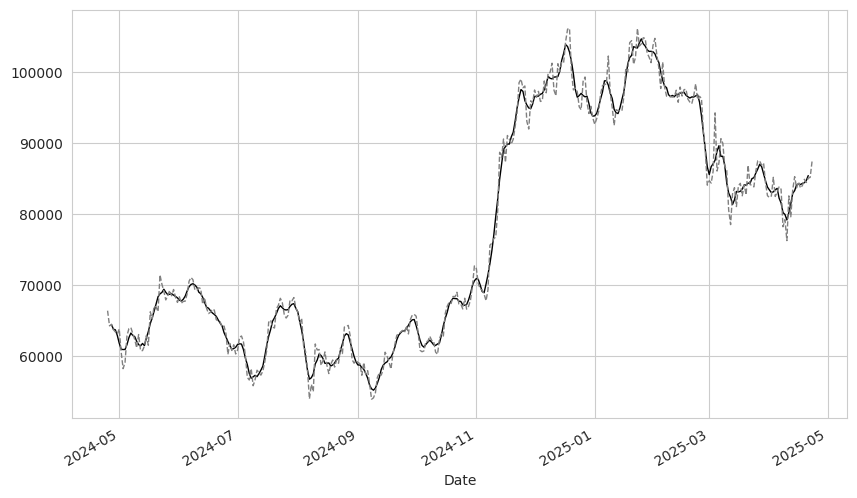

In [35]:
ma.plot(figsize=(10,6), color='black', linewidth=1)
df['Open'].plot(color='gray', linestyle='--', linewidth=1);

---
## 🅰️ Your Turn — Assignment 2

Two dataset choices:
1.   Expand on your Airbnb Data with  calendar.csv or reviews.csv
2.   Choose your own dataset(s) given your interests and expertise.

Either way, use some of the tools we covered today (text analysis, time series, or combining datasets) or some advanced tools from extra notebooks (networks and geographical data).

**Friday 9h45: Present your preliminary findings**
2 slides - 2 minutes
Submit your slides by 9h45 Friday morning.

**Sunday 17h00: Submit your final Assignment 2**

# Reference

This notebook is based on an original version by Miguel Ángel Canela (2022) and Enric Junqué de Fortuny (2025).